### DEMO2: Overview of using fusion model Bimodal Deep AutoEncoder ([BDAE](https://link.springer.com/chapter/10.1007/978-3-319-46672-9_58)) to train the synthtic dataset, and using SVM/PCA/TSNE to evaluate the results.

##### Pipeline:
1. Load synthetic neural (27 ch) + behavior (1 ch) data and labels.
2. Preprocess both modalities with **sliding-window Differential Entropy (DE)** features.
3. Train a **Bimodal Deep AutoEncoder (BDAE)** to learn a fused latent representation.
4. Evaluate representations using **Linear SVM** and visualize with **PCA / t-SNE** + heatmap.

In [ ]:
# import
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from scipy.stats import differential_entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Plot style
cm2inch = 1.0 / 2.54
mpl.rcParams["axes.edgecolor"] = "k"
mpl.rcParams["axes.facecolor"] = "w"
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams.update({'font.size': 10})
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams["font.family"] = "Helvetica"
sns.set_style("whitegrid")

#### 1. Load and merge synthetic data (from path: dataset\synthetic_data)

Each file contains different labels' signal; we concatenate them into a single dataset and assign per-sample labels.

In [18]:
data_root = '../dataset/synthetic_data'

def load_and_merge_data():
    neural_data_list = []
    behavior_data_list = []
    labels_list = []
    
    label_dirs = sorted(os.listdir(data_root))
    
    for label_idx, label_dir in enumerate(label_dirs):
        label_path = os.path.join(data_root, label_dir)
        files = sorted(os.listdir(label_path))
        
        neural_files = sorted([f for f in files if f.startswith('neural_data') and f.endswith('.npy')])
        behavior_files = sorted([f for f in files if f.startswith('behavior_data') and f.endswith('.npy')])
        
        for n_file, b_file in zip(neural_files, behavior_files):
            neural_path = os.path.join(label_path, n_file)
            behavior_path = os.path.join(label_path, b_file)
            
            neural_data_list.append(np.load(neural_path, allow_pickle=True))   # (151, 27)
            behavior_data_list.append(np.load(behavior_path, allow_pickle=True)) # (151, 1)
            
            labels_list.extend([label_idx] * 151)

    neural_data = np.concatenate(neural_data_list, axis=0)   # (453, 27)
    behavior_data = np.concatenate(behavior_data_list, axis=0) # (453, 1)
    labels = np.array(labels_list)                             # (453,)

    return neural_data, behavior_data, labels

Neural data shape: (453, 27)
Behavior data shape: (453, 1)
Labels shape: (453,)


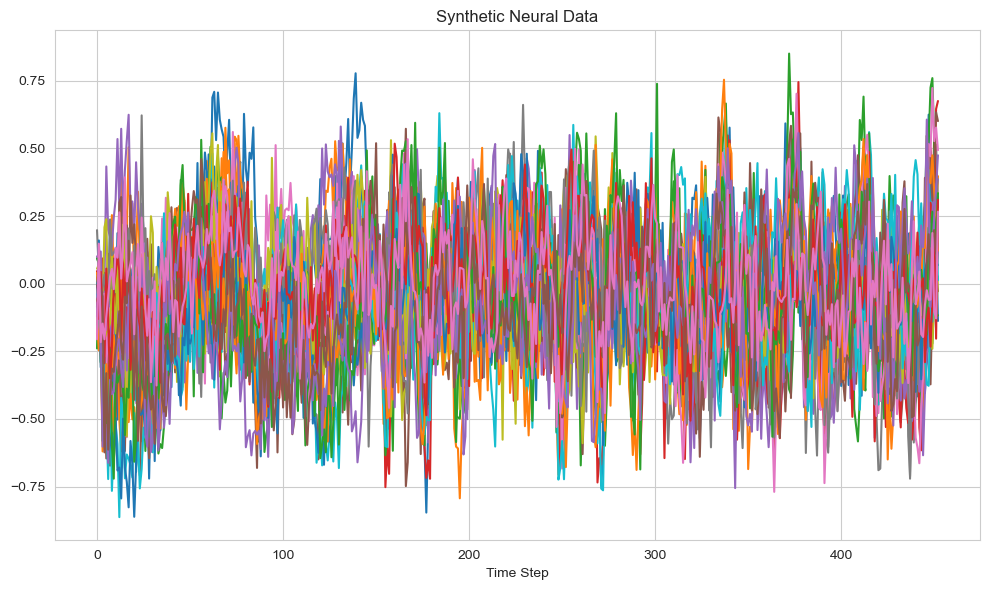

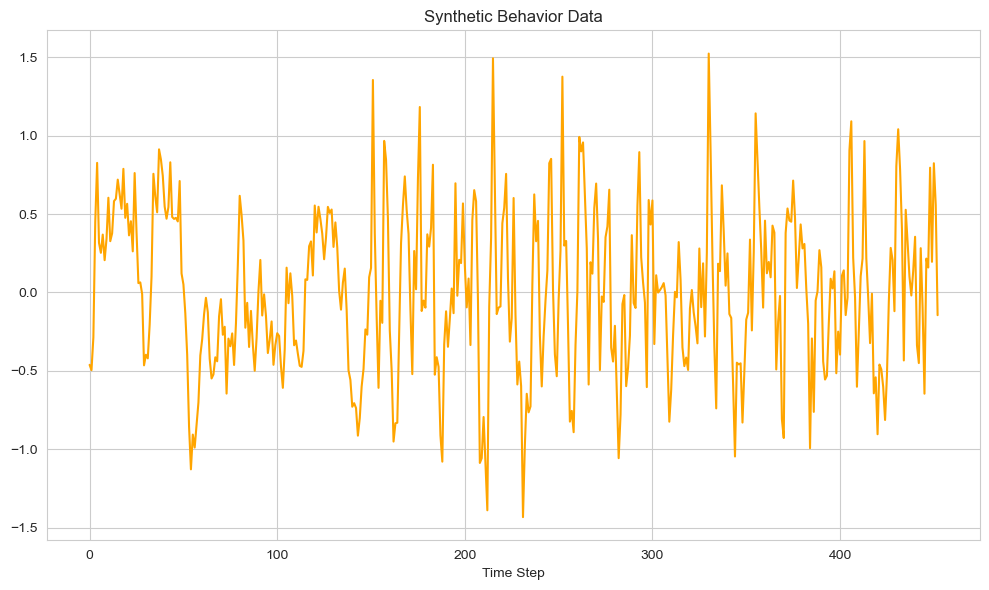

In [19]:
neural_data, behavior_data, labels = load_and_merge_data()
print(f"Neural data shape: {neural_data.shape}")
print(f"Behavior data shape: {behavior_data.shape}")
print(f"Labels shape: {labels.shape}")

plt.figure(figsize=(10, 6))
for i in range(neural_data.shape[1]):
    plt.plot(neural_data[:, i], label=f'Channel {i+1}')
plt.title("Synthetic Neural Data")
plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(behavior_data.flatten(), color='orange')
plt.title("Synthetic Behavior Data")
plt.xlabel("Time Step")
plt.tight_layout()
plt.show()

#### 2. Preprocessing: Sliding-window Differential Entropy (DE)
 
For each channel, we compute DE over a local window around each time step.
This converts raw time series into a feature vector per time step, for both modalities.

In [20]:
def compute_de_sliding(signal, window_size=10, step=1):
    n = len(signal)
    de_values = np.zeros(n)
    half_window = window_size // 2
    for i in range(0, n, step):
        start = max(0, i - half_window)
        end = min(n, i + half_window + 1)
        segment = signal[start:end]
        de_values[i] = differential_entropy(segment)
    return de_values

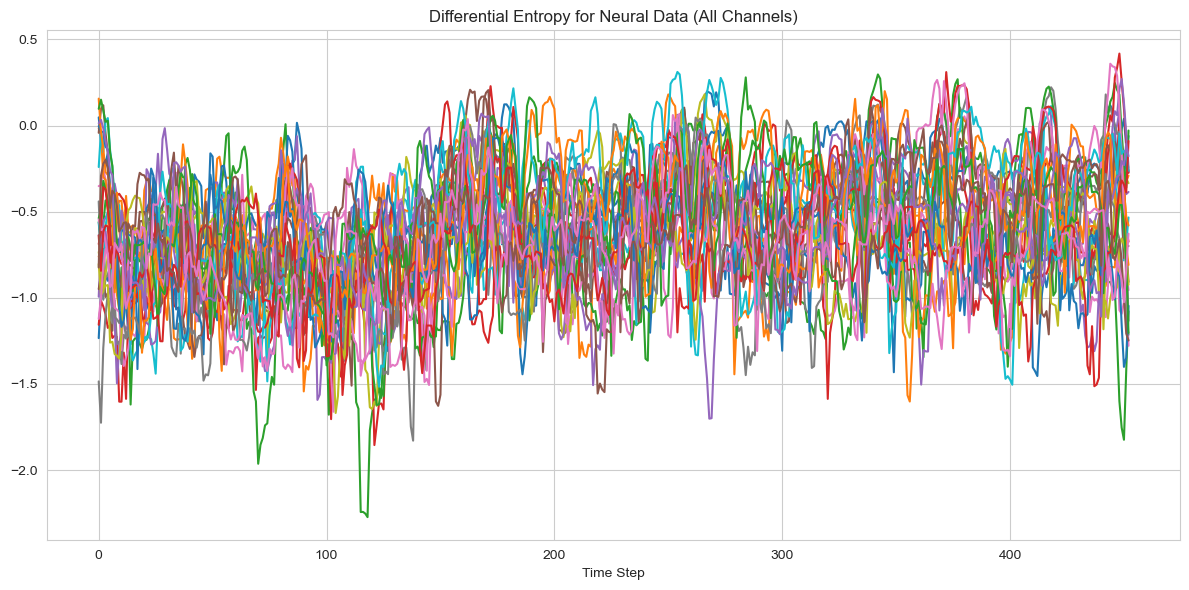

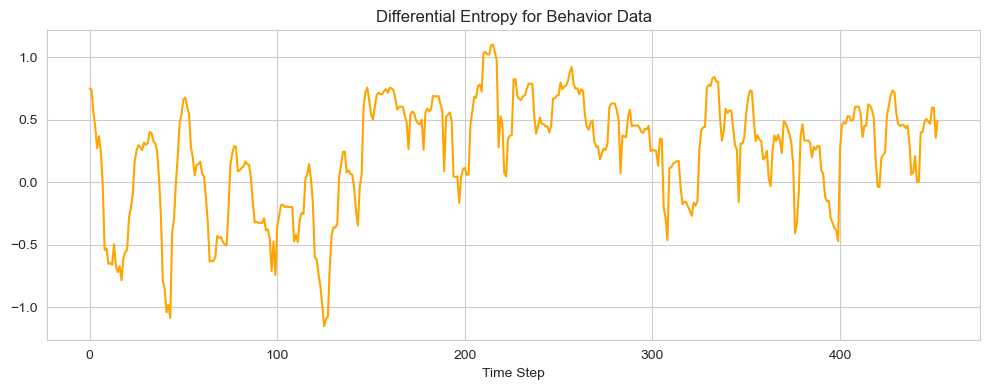

In [21]:
window_size = 10
step = 1

# neural data
n_samples, n_channels = neural_data.shape
de_neural = np.zeros((n_samples, n_channels))
for ch in range(n_channels):
    de_neural[:, ch] = compute_de_sliding(neural_data[:, ch], window_size=window_size, step=step)

# behavior data
behavior_data_1d = behavior_data.flatten()
de_behavior = compute_de_sliding(behavior_data_1d, window_size=window_size, step=step)
de_behavior = de_behavior.reshape(-1, 1)

# plot
plt.figure(figsize=(12, 6))
for ch in range(de_neural.shape[1]):
    plt.plot(de_neural[:, ch], lw=1.5)
plt.xlabel("Time Step")
plt.title("Differential Entropy for Neural Data (All Channels)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(de_behavior.flatten(), color='orange')
plt.xlabel("Time Step")
plt.title("Differential Entropy for Behavior Data")
plt.tight_layout()
plt.show()

In [22]:
neural_dataset = {
    'data':   de_neural,
    'labels': labels
}

behavior_dataset = {
    'data':   de_behavior,
    'labels': labels
}

print("Neural DE features shape:", de_neural.shape)
print("Behavior DE features shape:", de_behavior.shape)
print("Labels shape:", labels.shape)

Neural DE features shape: (453, 27)
Behavior DE features shape: (453, 1)
Labels shape: (453,)


#### 3. Train the BDAE (fast mode)

To keep this demo runnable during an interview, we train **one** BDAE configuration.
(Full hyperparameter sweeps are done offline; we can load `.pkl` results from another result folder.)

In [23]:
# Load Data
neural_data = de_neural
behavior_data = de_behavior
labels = labels

# MinMax Normalization
scaler_neural = MinMaxScaler()
scaler_behavior = MinMaxScaler()

neural_data = scaler_neural.fit_transform(neural_data)
behavior_data = scaler_behavior.fit_transform(behavior_data)

# Train-Validation-Test Split (60/20/20)
neural_temp, neural_test, behavior_temp, behavior_test, labels_temp, labels_test = train_test_split(
    neural_data, behavior_data, labels, test_size=0.2, random_state=42, shuffle=True
)

neural_train, neural_val, behavior_train, behavior_val, labels_train, labels_val = train_test_split(
    neural_temp, behavior_temp, labels_temp, test_size=0.25, random_state=42, shuffle=True
)

In [ ]:
import tensorflow as tf
from keras import backend as K
from keras.layers import Dense, Input, Concatenate, Lambda, Dropout
from keras.models import Model
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping
from sklearn.neural_network import BernoulliRBM

from keras.backend.tensorflow_backend import set_session
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.Session(config=config)
set_session(sess)

# Hyperparameters
# batch_sizes = [50]
# n_iter_list = [20, 50]
# hidden_units_list = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
# epochs_list = [500, 300, 200, 100, 50, 10]
# learning_rate_list = [0.01]

batch_sizes = [50]
n_iter_list = [20]
hidden_units_list = [5]
epochs_list = [10]
learning_rate_list = [0.01]

# Train BDAE
for this_bs in batch_sizes:
    # only for fast mode
    bdae_transformed_dir = f'./bdae_gpjm_data3_fm_bs{this_bs}/'
    os.makedirs(bdae_transformed_dir, exist_ok=True)

    for this_niter in n_iter_list:
        for this_hidden in hidden_units_list:
            for this_epoch in epochs_list:
                for this_lr in learning_rate_list:
                    print("\n========================================")
                    print(f"Training BDAE | batch_size={this_bs} | "
                          f"n_iter={this_niter} | hidden_units={this_hidden} | "
                          f"epochs={this_epoch} | lr={this_lr}")
                    print("========================================\n")

                    # === Train RBMs ===
                    rbm1 = BernoulliRBM(n_components=this_hidden, batch_size=this_bs, n_iter=this_niter, learning_rate=this_lr, random_state=42)
                    rbm2 = BernoulliRBM(n_components=this_hidden, batch_size=this_bs, n_iter=this_niter, learning_rate=this_lr, random_state=42)
                    rbm3 = BernoulliRBM(n_components=this_hidden, batch_size=this_bs, n_iter=this_niter, learning_rate=this_lr, random_state=42)

                    print('Training RBM 1 (Neural Data)')
                    rbm1.fit(neural_train)
                    hidden_neural = rbm1.transform(neural_train)
                    weights_neural = rbm1.components_

                    print('Training RBM 2 (Behavior Data)')
                    rbm2.fit(behavior_train)
                    hidden_behavior = rbm2.transform(behavior_train)
                    weights_behavior = rbm2.components_

                    print('Training RBM 3 (Fusion)')
                    concat_data = np.append(hidden_neural, hidden_behavior, axis=1)
                    rbm3.fit(concat_data)
                    weights_merge = rbm3.components_

                    def get_neural_part(nparray): return nparray[:, :this_hidden]
                    def get_behavior_part(nparray): return nparray[:, this_hidden:]

                    # Build Model
                    x_input = Input(shape=(neural_data.shape[1],), name='x_input')
                    y_input = Input(shape=(behavior_data.shape[1],), name='y_input')

                    x_hidden = Dense(this_hidden, weights=[weights_neural.T, rbm1.intercept_hidden_], activation='sigmoid', name='x_hidden')(x_input)
                    y_hidden = Dense(this_hidden, weights=[weights_behavior.T, rbm2.intercept_hidden_], activation='sigmoid', name='y_hidden')(y_input)

                    merge_xy = Concatenate()([x_hidden, y_hidden])
                    feature_layer = Dense(this_hidden, weights=[weights_merge.T, rbm3.intercept_hidden_], activation='sigmoid', name='merged')(merge_xy)
                    feature_layer = Dropout(0.2)(feature_layer)

                    merge_xy_t = Dense(2 * this_hidden, weights=[weights_merge, rbm3.intercept_visible_], activation='sigmoid', name='merge_t')(feature_layer)
                    x_hidden_t = Lambda(get_neural_part)(merge_xy_t)
                    y_hidden_t = Lambda(get_behavior_part)(merge_xy_t)

                    x_recon = Dense(neural_data.shape[1], weights=[weights_neural, rbm1.intercept_visible_], activation='sigmoid', name='x_recon')(x_hidden_t)
                    y_recon = Dense(behavior_data.shape[1], weights=[weights_behavior, rbm2.intercept_visible_], activation='sigmoid', name='y_recon')(y_hidden_t)

                    model = Model(inputs=[x_input, y_input], outputs=[x_recon, y_recon])
                    model.compile(optimizer=RMSprop(lr=this_lr), loss='mean_squared_error')

                    early_stop = EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)

                    print(f'Training model with {this_epoch} epochs, batch_size={this_bs}')
                    history = model.fit(
                        [neural_train, behavior_train],
                        [neural_train, behavior_train],
                        validation_data=([neural_val, behavior_val], [neural_val, behavior_val]),
                        epochs=this_epoch,
                        batch_size=this_bs,
                        verbose=1,
                        callbacks=[early_stop]
                    )

                    # Save Loss Curve
                    plt.figure()
                    plt.plot(history.history['loss'], label='Train Loss')
                    if 'val_loss' in history.history:
                        plt.plot(history.history['val_loss'], label='Val Loss')
                    plt.title(f"Loss Curve - n_iter={this_niter}, hidden={this_hidden}, epochs={this_epoch}, lr={this_lr}, bs={this_bs}")
                    plt.xlabel("Epoch")
                    plt.ylabel("Loss (MSE)")
                    plt.legend()
                    loss_plot_filename = f"loss_{this_niter}_{this_hidden}_{this_epoch}_{this_lr}.png"
                    plt.savefig(os.path.join(bdae_transformed_dir, loss_plot_filename))
                    plt.close()

                    # Extract and Save Features
                    print('Extracting Features...')
                    feature_res = K.function([model.input[0], model.input[1]], [model.get_layer("merged").output])
                    train_features = feature_res([neural_train, behavior_train])[0]
                    test_features = feature_res([neural_test, behavior_test])[0]

                    feature_filename = f'features_{this_niter}_{this_hidden}_{this_epoch}_{this_lr}.pkl'
                    feature_path = os.path.join(bdae_transformed_dir, feature_filename)
                    val_features = feature_res([neural_val, behavior_val])[0]

                    with open(feature_path, 'wb') as f:
                        pickle.dump({
                            "train_features": train_features,
                            "train_labels": labels_train,
                            "val_features": val_features,
                            "val_labels": labels_val,
                            "test_features": test_features,
                            "test_labels": labels_test
                        }, f)

                    weights_filename = f"weights_{this_niter}_{this_hidden}_{this_epoch}_{this_lr}.h5"
                    weights_path = os.path.join(bdae_transformed_dir, weights_filename)
                    model.save_weights(weights_path)
                    print(f"Saved model weights to: {weights_path}")

print("All Training Complete!")



Training BDAE | batch_size=50 | n_iter=20 | hidden_units=5 | epochs=10 | lr=0.01

Training RBM 1 (Neural Data)
Training RBM 2 (Behavior Data)
Training RBM 3 (Fusion)
Training model with 10 epochs, batch_size=50
Train on 271 samples, validate on 91 samples
Epoch 1/10
271/271 [==============================] - 12s 44ms/step - loss: 0.0839 - x_recon_loss: 0.0385 - y_recon_loss: 0.0454 - val_loss: 0.0790 - val_x_recon_loss: 0.0365 - val_y_recon_loss: 0.0426
Epoch 2/10
271/271 [==============================] - 0s 155us/step - loss: 0.0751 - x_recon_loss: 0.0359 - y_recon_loss: 0.0393 - val_loss: 0.0759 - val_x_recon_loss: 0.0358 - val_y_recon_loss: 0.0401
Epoch 3/10
271/271 [==============================] - 0s 114us/step - loss: 0.0747 - x_recon_loss: 0.0357 - y_recon_loss: 0.0391 - val_loss: 0.0755 - val_x_recon_loss: 0.0357 - val_y_recon_loss: 0.0398
Epoch 4/10
271/271 [==============================] - 0s 106us/step - loss: 0.0744 - x_recon_loss: 0.0356 - y_recon_loss: 0.0388 - val_lo

#### 3. Evaluate the results
- quantitatively predictive (Linear SVM accuracy),
- qualitatively structured (PCA/t-SNE clustering + heatmap blocks).

In [ ]:
import os
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# from the results runned in complete hyperparameters
pkl_folder = './bdae_gpjm_data3_bs50'

In [32]:
# Load data
def prepare_split_result(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    result = {"file": os.path.basename(file_path)}
    for split in ['train', 'val', 'test']:
        if f"{split}_features" in data and f"{split}_labels" in data:
            result[f"{split}_features"] = np.array(data[f"{split}_features"])
            result[f"{split}_labels"] = np.array(data[f"{split}_labels"])
    return result

In [33]:
# SVM
def evaluate_svm(train_X, train_y, val_X, val_y, test_X, test_y):
    X_tr = np.vstack([train_X, val_X])
    y_tr = np.concatenate([train_y, val_y])

    pipe = make_pipeline(
        StandardScaler(),
        LinearSVC(C=1.0, max_iter=10000, dual=False, random_state=42)
    )

    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(test_X)

    acc = accuracy_score(test_y, y_pred)
    f1 = f1_score(test_y, y_pred, average='weighted')
    cm = confusion_matrix(test_y, y_pred)
    
    return acc, f1, cm

In [34]:
# Visualization: PCA / t-SNE (2D / 3D)
def visualize_dim_reduction(X, y, method='pca', dims=2, split_name='train'):
    assert method in ['pca', 'tsne']
    assert dims in [2, 3]

    if method == 'pca':
        model = PCA(n_components=dims, random_state=0)
        X_proj = model.fit_transform(X)
    else:
        model = TSNE(n_components=dims, random_state=0, init='pca')
        X_proj = model.fit_transform(X)

    fig = plt.figure(figsize=(18 * cm2inch, 12.4 * cm2inch))

    if dims == 3:
        ax = fig.add_subplot(111, projection='3d')
        for label in np.unique(y):
            pts = X_proj[y == label]
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=18, label=f"Label {int(label)+1}")
        ax.set_title(f"{split_name.upper()} - {method.upper()} 3D")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.set_zlabel("Dim 3")
    else:
        ax = fig.add_subplot(111)
        for label in np.unique(y):
            pts = X_proj[y == label]
            ax.scatter(pts[:, 0], pts[:, 1], s=18, label=f"Label {int(label)+1}")
        ax.set_title(f"{split_name.upper()} - {method.upper()} 2D")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

    ax.grid(True)
    ax.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Visualization: Heatmap visualization
def visualize_heatmap(train_X, train_y, test_X, test_y):
    X_combined = np.concatenate([train_X, test_X], axis=0)
    y_combined = np.concatenate([train_y, test_y], axis=0)

    sort_idx = np.argsort(y_combined)
    X_sorted = X_combined[sort_idx]
    y_sorted = y_combined[sort_idx]

    fig = plt.figure(figsize=(18 * cm2inch, 12.4 * cm2inch))
    ax = fig.add_subplot(111)

    sns.heatmap(X_sorted, cmap='viridis', yticklabels=False, ax=ax)

    changes = np.where(np.diff(y_sorted) != 0)[0] + 1
    for c in changes:
        ax.hlines(c, *ax.get_xlim(), colors='k', linewidth=0.5)

    ax.set_title("Heatmap (Train + Test, sorted by label)")
    ax.set_xlabel("Feature dimension")
    ax.set_ylabel("Samples (sorted)")
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [35]:
# Main
linear_results = []

for filename in os.listdir(pkl_folder):
    if filename.endswith(".pkl"):
        file_path = os.path.join(pkl_folder, filename)
        result = prepare_split_result(file_path)

        X_train = np.concatenate([
            result["train_features"],
            result.get("val_features", np.empty((0, result["train_features"].shape[1])))
        ], axis=0)
        y_train = np.concatenate([
            result["train_labels"],
            result.get("val_labels", np.empty((0,), dtype=result["train_labels"].dtype))
        ], axis=0)
        X_test = result["test_features"]
        y_test = result["test_labels"]

        # SVM
        acc, f1, cm = evaluate_svm(
            result["train_features"], result["train_labels"],
            result.get("val_features", np.empty((0, result["train_features"].shape[1]))),
            result.get("val_labels", np.empty((0,), dtype=result["train_labels"].dtype)),
            X_test, y_test
        )

        result.update({
            "train_features": X_train,
            "train_labels": y_train,
            "test_features": X_test,
            "test_labels": y_test,
            "svm_accuracy": acc,
            "svm_f1_score": f1,
            "confusion_matrix": cm
        })
        linear_results.append(result)

best_result = max(linear_results, key=lambda x: x["svm_accuracy"])
file_id = best_result["file"].replace(".pkl", "")

print(f"\nBest Linear SVM Accuracy File: {file_id}")
print(f"  Accuracy: {best_result['svm_accuracy']:.4f}")
print(f"  F1 Score: {best_result['svm_f1_score']:.4f}")
print("  Confusion Matrix:")
print(best_result["confusion_matrix"])


Best Linear SVM Accuracy File: features_20_50_500_0.01
  Accuracy: 0.9231
  F1 Score: 0.9228
  Confusion Matrix:
[[33  1  0]
 [ 0 23  1]
 [ 2  3 28]]


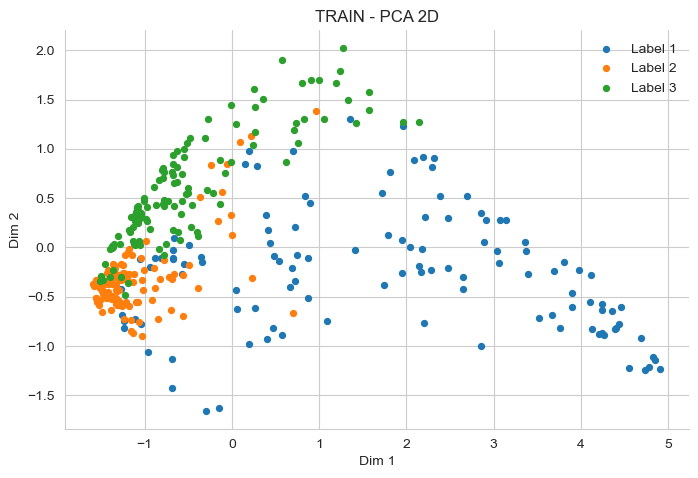

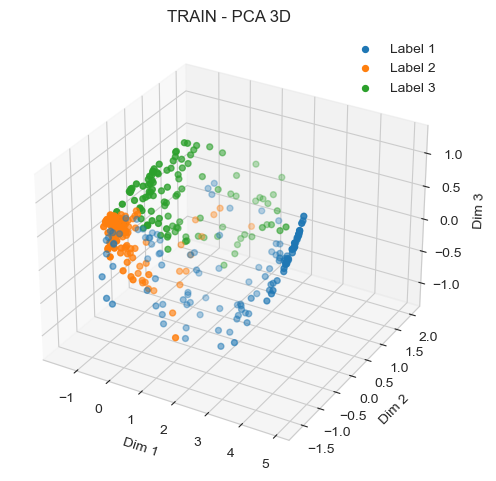

d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


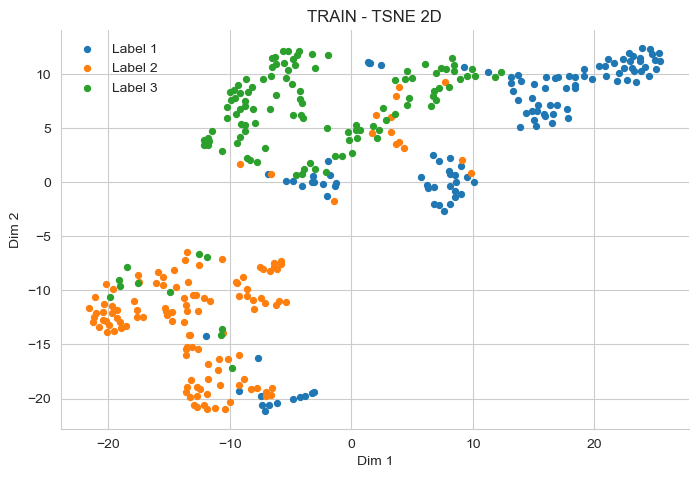

d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


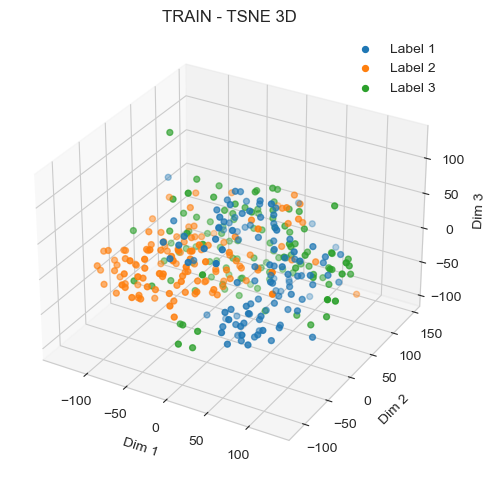

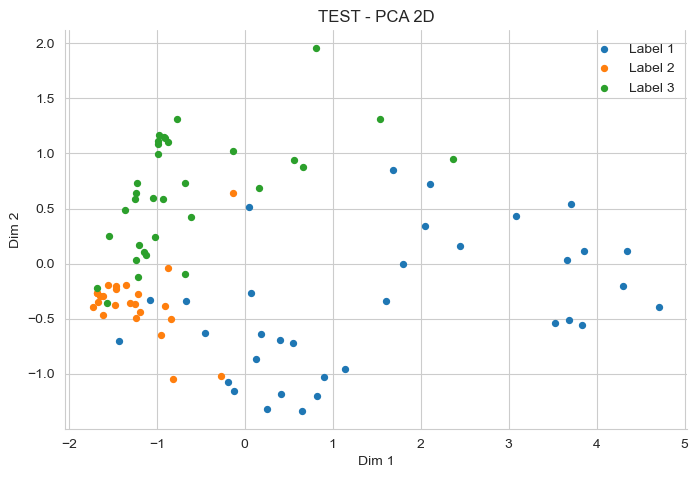

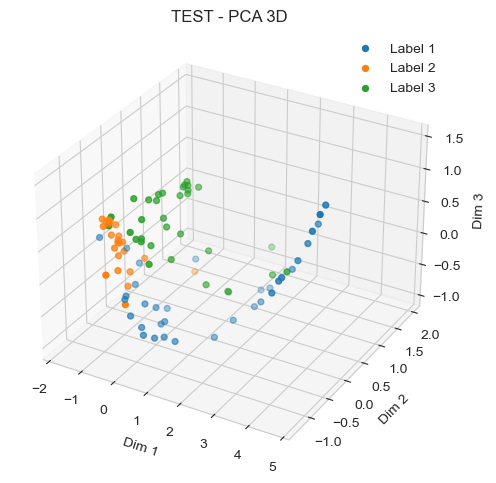

d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


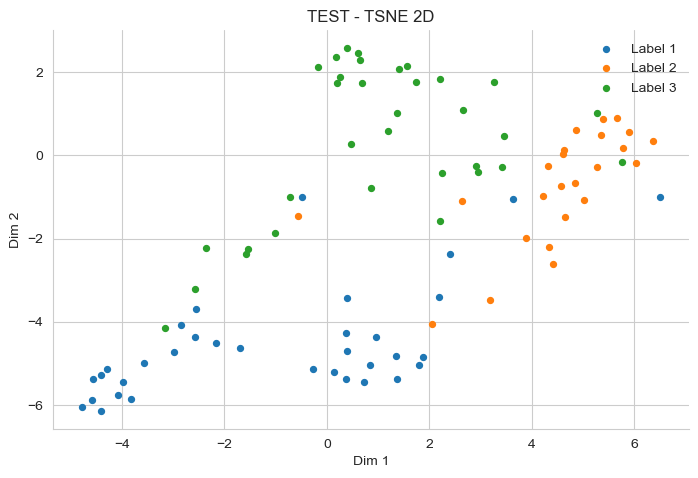

d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
d:\Anaconda3\envs\bdae\lib\site-packages\sklearn\manifold\_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


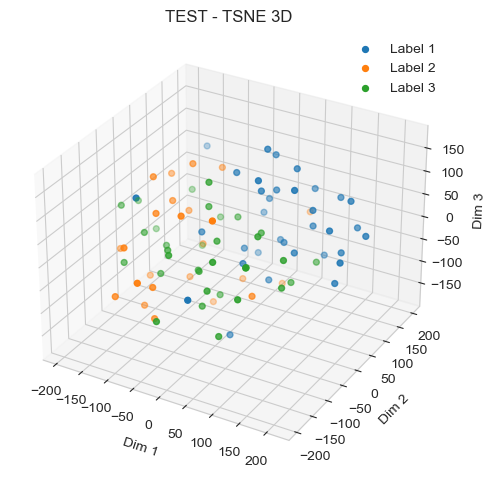

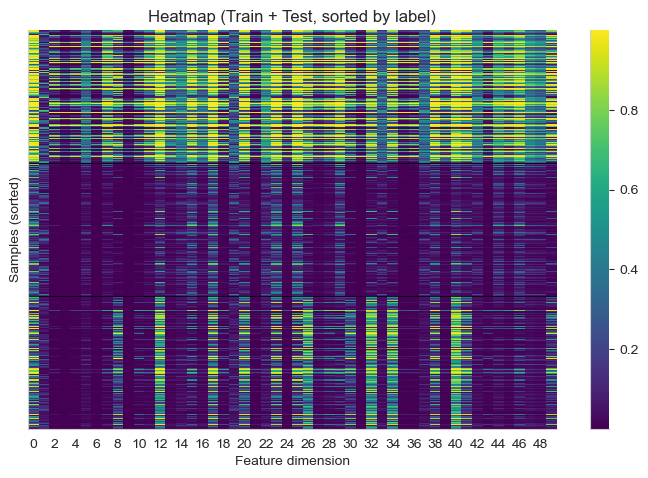

In [36]:
# Visualize best result
for split in ['train', 'test']:
    X = best_result[f"{split}_features"]
    y = best_result[f"{split}_labels"]

    for method in ['pca', 'tsne']:
        for dims in [2, 3]:
            visualize_dim_reduction(X, y, method=method, dims=dims, split_name=split)

visualize_heatmap(
    best_result["train_features"], best_result["train_labels"],
    best_result["test_features"], best_result["test_labels"]
)